# Pipeline Pembelajaran Mesin: Klasifikasi Gestur Tangan MPU6050
**Tugas Besar Pengganti UAS Genap 2025/2026**  
Mata Kuliah: Pembelajaran Mesin dan Aplikasi (ABK4ABB3)  

Notebook ini memproses data gerakan tangan mentah dari MPU6050, mengekstraksi 36 fitur statistik per window (1.5 detik, 50% overlap), melatih model **Dummy Classifier** (baseline), **Random Forest** (pembanding), dan **Multilayer Perceptron (MLP)** (model utama), serta mengekspor model MLP ke format **TFLite Micro** (`model.h`) untuk di-deploy di ESP32-S3.

In [1]:
# 1. Import Library yang Dibutuhkan
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)
print("Pandas Version:", pd.__version__)
print("Numpy Version:", np.__version__)

TensorFlow Version: 2.21.0
Pandas Version: 3.0.3
Numpy Version: 1.26.2


## 2. Pemuatan Data & Ekstraksi Fitur (Feature Extraction)
Data mentah berupa file CSV berisi sumbu sensor: `ax, ay, az, gx, gy, gz`.  
Kita akan memotong data menjadi **window berukuran 1.5 detik** (150 sampel pada 100Hz) dengan **overlap 50%** (75 sampel geseran).  
Untuk setiap window, kita menghitung 6 fitur statistik per sumbu: `mean`, `std`, `min`, `max`, `range`, dan `RMS` (total 36 fitur).

In [6]:
# Fungsi pembantu untuk menghitung Root Mean Square (RMS)
def compute_rms(series):
    return np.sqrt(np.mean(series ** 2))

# Fungsi utama ekstraksi fitur
# CATATAN: file CSV sekarang per-CLASS (idle.csv, wave.csv, ...), bukan per-subject.
# Maka subject & label dibaca dari KOLOM, bukan dari nama file.
def extract_features_from_csv(data_dir, window_size=150, step_size=75):
    csv_files = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)
    print(f"Ditemukan {len(csv_files)} file CSV.")

    all_windows = []

    for file_path in csv_files:
        df = pd.read_csv(file_path)
        df = df.dropna().reset_index(drop=True)
        if df.empty:
            continue

        # Subject & label WAJIB ada sebagai kolom
        if 'participant_id' not in df.columns or 'label' not in df.columns:
            print(f"Skip {os.path.basename(file_path)}: kolom participant_id/label tidak ada.")
            continue

        # Batas segmen: ganti subject, ATAU ganti label, ATAU lompatan waktu > 1 detik.
        # 'subj_changed' krusial -> mencegah satu window mencampur dua orang berbeda.
        subj_changed  = df['participant_id'] != df['participant_id'].shift(1)
        label_changed = df['label']          != df['label'].shift(1)
        time_gap      = df['timestamp_ms'].diff() > 1000
        df['segment_boundary'] = subj_changed | label_changed | time_gap
        df['segment_id'] = df['segment_boundary'].cumsum()

        # Windowing per segmen
        for segment_val, group in df.groupby('segment_id'):
            participant_id = group['participant_id'].iloc[0]
            label          = group['label'].iloc[0]
            session_id     = group['session_id'].iloc[0] if 'session_id' in group.columns else "S1"
            n_samples = len(group)

            if n_samples < window_size:
                continue

            repetition_id = f"{participant_id}_seg{segment_val}"
            for start_idx in range(0, n_samples - window_size + 1, step_size):
                window_df = group.iloc[start_idx : start_idx + window_size]

                features = {
                    'participant_id': participant_id,
                    'session_id': session_id,
                    'repetition_id': repetition_id,
                    'label': label
                }

                for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
                    series = window_df[col].values
                    features[f'{col}_mean']  = np.mean(series)
                    features[f'{col}_std']   = np.std(series)
                    features[f'{col}_min']   = np.min(series)
                    features[f'{col}_max']   = np.max(series)
                    features[f'{col}_range'] = features[f'{col}_max'] - features[f'{col}_min']
                    features[f'{col}_rms']   = compute_rms(series)

                all_windows.append(features)

    result_df = pd.DataFrame(all_windows)
    return result_df

# Jalankan ekstraksi fitur — sesuaikan path dengan lokasi 5 file per-class
data_directory = "./data"          # kalau file langsung di dalam data_training/
df_features = extract_features_from_csv(data_directory)
print(f"\nDataset hasil ekstraksi: {df_features.shape}")

df_features.to_csv("dataset_features.csv", index=False)
print("Fitur berhasil disimpan ke: dataset_features.csv")

Ditemukan 5 file CSV.

Dataset hasil ekstraksi: (176, 40)
Fitur berhasil disimpan ke: dataset_features.csv


## 3. Analisis Data Eksploratif (EDA) Singkat
Mari kita lihat distribusi data berdasarkan gestur (kelas target) dan partisipan yang berpartisipasi.

Ditemukan 5 file CSV.
✅ Selesai! Data fitur berhasil di-save ke dataset_features.csv
=== Distribusi Kelas Target ===
label
lift      38
push      36
wave      36
rotate    34
idle      32
Name: count, dtype: int64

=== Distribusi Berdasarkan Partisipan ===
participant_id
hikhmal    32
ramzy      25
dzaki      24
rizki      23
gilang     21
dafa       20
septian    16
irvan      15
Name: count, dtype: int64


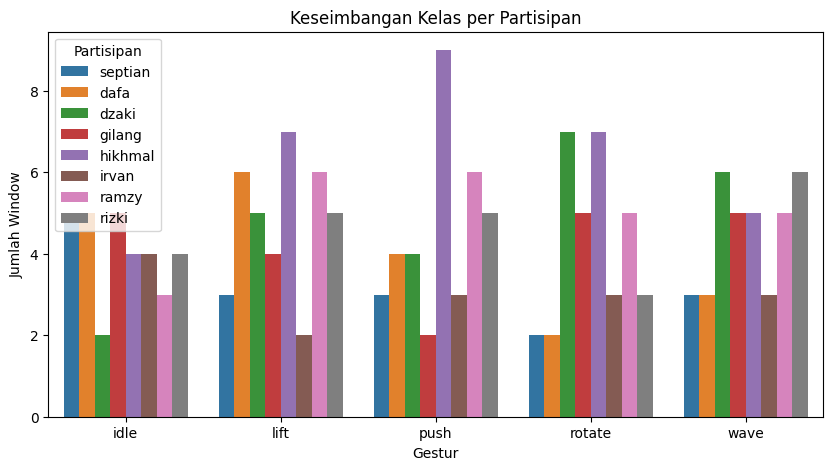

In [8]:
data_directory = r"./data"   # pastikan idle.csv, wave.csv, dst ada di sini
df_features = extract_features_from_csv(data_directory)

df_features.to_csv("dataset_features.csv", index=False)
print("✅ Selesai! Data fitur berhasil di-save ke dataset_features.csv")

print("=== Distribusi Kelas Target ===")
print(df_features['label'].value_counts())
print("\n=== Distribusi Berdasarkan Partisipan ===")
print(df_features['participant_id'].value_counts())

# Plot countplot untuk melihat keseimbangan data
plt.figure(figsize=(10, 5))
sns.countplot(data=df_features, x='label', hue='participant_id')
plt.title("Keseimbangan Kelas per Partisipan")
plt.xlabel("Gestur")
plt.ylabel("Jumlah Window")
plt.legend(title="Partisipan")
plt.show()

## 4. Pembagian Data (Train/Val/Test Split) & Standardisasi
Untuk mensimulasikan penggunaan nyata (generalization), kita harus membagi data berdasarkan **partisipan** agar data partisipan tes tidak bocor (*data leakage*) ke dalam data training.
* **Training & Validation:** Partisipan `rizqyyy`, `bungg`, `hikhmal`, `marco`, `ramzy`.
* **Testing:** Partisipan `abdul`.

Setelah di-split, fitur akan dinormalisasi menggunakan `StandardScaler`.

In [11]:
# Mapping label text ke numerik
label_mapping = {'idle': 0, 'wave': 1, 'rotate': 2, 'push': 3, 'lift': 4}
df_features['target'] = df_features['label'].map(label_mapping)

# Filter nama kolom fitur (yang bertipe statistik)
feature_cols = [c for c in df_features.columns if c not in ['participant_id', 'session_id', 'repetition_id', 'label', 'target']]

# Tentukan subjek tes untuk evaluasi akhir
test_subject = 'dafa' # Ganti dengan partisipan yang ingin dijadikan Test Set
print(f"Menggunakan partisipan '{test_subject}' sebagai Test Set.\n")

# Split dataset
train_df = df_features[df_features['participant_id'] != test_subject].copy()
test_df = df_features[df_features['participant_id'] == test_subject].copy()

X_train = train_df[feature_cols].values
y_train = train_df['target'].values
groups_train = train_df['participant_id'].values

X_test = test_df[feature_cols].values
y_test = test_df['target'].values

print(f"Ukuran Training & Validation Set: {X_train.shape}")
print(f"Ukuran Test Set (Partisipan {test_subject}): {X_test.shape}")

# Normalisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ekspor nilai Mean dan Standard Deviation untuk diintegrasikan ke kode ESP32
print("\n========================================================")
print("   SALIN CODE BERIKUT KE KODE ESP32 (FIRMWARE UTAMA)   ")
print("========================================================")
print(f"const int NUM_FEATURES = {len(feature_cols)};")
print("const float scaler_mean[] = {")
print("  " + ", ".join([f"{v:.8f}f" for v in scaler.mean_]))
print("};")
print("const float scaler_std[] = {")
print("  " + ", ".join([f"{v:.8f}f" for v in scaler.scale_]))
print("};\n")
print("// Penjelasan urutan fitur:")
for idx, col in enumerate(feature_cols):
    print(f"// Indeks ke-{idx}: {col}")

# === Tulis langsung ke scaler_params.h (dipakai oleh .ino via #include) ===
def fmt(arr):
    lines = []
    for i in range(0, len(arr), 6):
        chunk = arr[i:i+6]
        lines.append("  " + ", ".join(f"{v:.8f}f" for v in chunk) + ",")
    return "\n".join(lines).rstrip(",")

header = f"""// scaler_params.h - DIHASILKAN OTOMATIS dari training (test_subject = '{test_subject}')
// Urutan fitur identik dengan ekstraksi di firmware.
#ifndef SCALER_PARAMS_H
#define SCALER_PARAMS_H

const int NUM_FEATURES = {len(feature_cols)};

const float scaler_mean[NUM_FEATURES] = {{
{fmt(scaler.mean_)}
}};

const float scaler_std[NUM_FEATURES] = {{
{fmt(scaler.scale_)}
}};

#endif // SCALER_PARAMS_H
"""

with open("scaler_params.h", "w") as f:
    f.write(header)
print("\n✅ scaler_params.h berhasil ditulis. Salin file ini ke folder Arduino bersama model.h")

Menggunakan partisipan 'dafa' sebagai Test Set.

Ukuran Training & Validation Set: (156, 36)
Ukuran Test Set (Partisipan dafa): (20, 36)

   SALIN CODE BERIKUT KE KODE ESP32 (FIRMWARE UTAMA)   
const int NUM_FEATURES = 36;
const float scaler_mean[] = {
  0.42872368f, 0.04282730f, 0.35268141f, 0.49796090f, 0.14527949f, 0.45264759f, 0.00709155f, 0.03701138f, -0.05669167f, 0.06569231f, 0.12238397f, 0.08177845f, -0.14074787f, 0.04063520f, -0.21283910f, -0.06801218f, 0.14482692f, 0.36271940f, 8.03777362f, 73.31675577f, -100.66335192f, 112.46711987f, 213.13047179f, 76.65750013f, 0.05006141f, 58.27087798f, -94.92122115f, 98.70562308f, 193.62684423f, 60.15455162f, -1.15590963f, 69.82196223f, -95.41394038f, 102.13760897f, 197.55154936f, 71.51666437f
};
const float scaler_std[] = {
  0.25445916f, 0.04252720f, 0.27272505f, 0.25188735f, 0.14353236f, 0.21750024f, 0.10309773f, 0.05394594f, 0.12709829f, 0.14069776f, 0.18133436f, 0.09094902f, 0.41513278f, 0.03668408f, 0.42068309f, 0.40529099f, 0.13640

## 5. Model Baseline: Dummy Classifier
Dummy Classifier digunakan sebagai nilai acuan terendah (*baseline*). Model ini memprediksi kelas target dengan strategi *stratified* (sesuai distribusi data training).

=== Laporan Evaluasi Baseline (Dummy) ===
              precision    recall  f1-score   support

        idle       0.20      0.20      0.20         5
        wave       0.50      0.67      0.57         3
      rotate       1.00      0.50      0.67         2
        push       0.20      0.25      0.22         4
        lift       0.40      0.33      0.36         6

    accuracy                           0.35        20
   macro avg       0.46      0.39      0.40        20
weighted avg       0.39      0.35      0.36        20



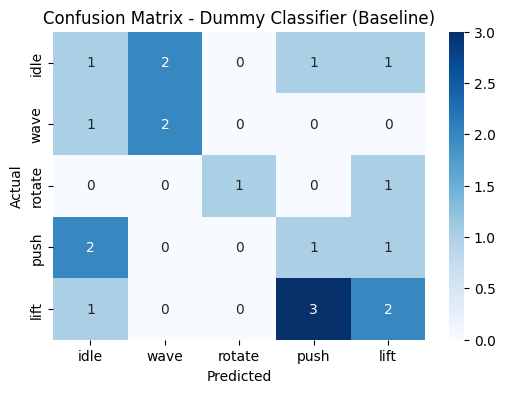

In [13]:
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train_scaled, y_train)

y_pred_dummy = dummy_clf.predict(X_test_scaled)

# Urutkan nama label sesuai nilai numerik (0..4) supaya selalu cocok dengan indeks confusion matrix
ordered_labels = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]

print("=== Laporan Evaluasi Baseline (Dummy) ===")
print(classification_report(y_test, y_pred_dummy, target_names=ordered_labels, zero_division=0))

# Heatmap Confusion Matrix
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues',
            xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title("Confusion Matrix - Dummy Classifier (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 6. Model Pembanding: Random Forest (RF)
Random Forest dilatih dengan validasi silang (Cross-Validation) bertipe `GroupKFold` agar tidak ada data dari partisipan yang sama bocor antara training dan validation fold.

Melakukan GridSearchCV dengan GroupKFold (splits=7)...
Hyperparameter terbaik: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

=== Laporan Evaluasi Random Forest (Test Set tunggal) ===
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00         5
        wave       1.00      1.00      1.00         3
      rotate       1.00      1.00      1.00         2
        push       1.00      0.75      0.86         4
        lift       0.86      1.00      0.92         6

    accuracy                           0.95        20
   macro avg       0.97      0.95      0.96        20
weighted avg       0.96      0.95      0.95        20



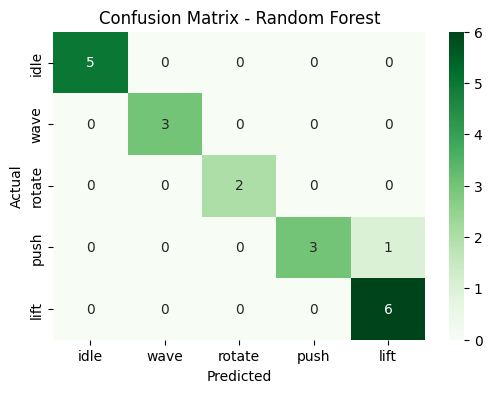


   EVALUASI CROSS-SUBJECT (Leave-One-Subject-Out)
  Test subject = dafa       | n_window =  20 | accuracy = 0.950
  Test subject = dzaki      | n_window =  24 | accuracy = 0.833
  Test subject = gilang     | n_window =  21 | accuracy = 0.857
  Test subject = hikhmal    | n_window =  32 | accuracy = 0.906
  Test subject = irvan      | n_window =  15 | accuracy = 0.867
  Test subject = ramzy      | n_window =  25 | accuracy = 0.800
  Test subject = rizki      | n_window =  23 | accuracy = 0.957
  Test subject = septian    | n_window =  16 | accuracy = 0.875
------------------------------------------------------------
Rata-rata akurasi cross-subject : 0.881 ± 0.051
Akurasi gabungan (semua window) : 0.881


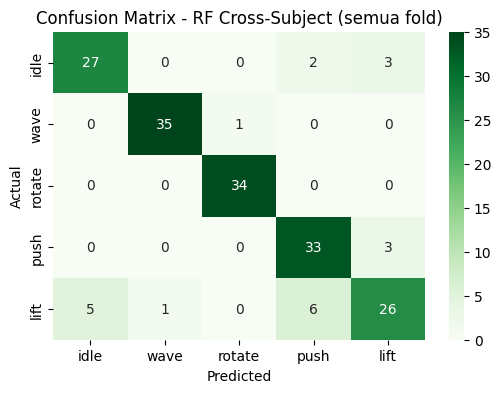

In [15]:
rf = RandomForestClassifier(random_state=42)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

# Setup GroupKFold (tiap fold memisahkan subject -> tidak ada kebocoran antar-orang)
unique_groups = len(np.unique(groups_train))
cv = GroupKFold(n_splits=unique_groups)

print(f"Melakukan GridSearchCV dengan GroupKFold (splits={unique_groups})...")
grid_rf = GridSearchCV(rf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train, groups=groups_train)

best_rf = grid_rf.best_estimator_
print("Hyperparameter terbaik:", grid_rf.best_params_)

# Urutkan nama label sesuai nilai numerik (0..4) supaya selalu cocok dengan indeks confusion matrix
ordered_labels = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]

# Evaluasi RF pada Test Set (single test_subject)
y_pred_rf = best_rf.predict(X_test_scaled)
print("\n=== Laporan Evaluasi Random Forest (Test Set tunggal) ===")
print(classification_report(y_test, y_pred_rf, target_names=ordered_labels, zero_division=0))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# EVALUASI CROSS-SUBJECT (Leave-One-Subject-Out, LOSO)
# Tiap subject bergiliran jadi test -> evaluasi memakai SELURUH data,
# bukan cuma 20 window dafa. Hasilnya jauh lebih stabil & jujur untuk paper.
# Memakai hyperparameter terbaik dari GridSearch di atas.
# ============================================================
from sklearn.model_selection import LeaveOneGroupOut

print("\n" + "="*60)
print("   EVALUASI CROSS-SUBJECT (Leave-One-Subject-Out)")
print("="*60)

# Pakai SEMUA data (gabung train + test), tiap subject sekali jadi test
X_all = df_features[feature_cols].values
y_all = df_features['target'].values
groups_all = df_features['participant_id'].values

logo = LeaveOneGroupOut()
fold_acc = []
all_y_true, all_y_pred = [], []

for train_idx, test_idx in logo.split(X_all, y_all, groups=groups_all):
    subj = groups_all[test_idx][0]

    # Scaler di-fit HANYA pada train fold (hindari kebocoran)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_all[train_idx])
    X_te = sc.transform(X_all[test_idx])

    model = RandomForestClassifier(random_state=42, **grid_rf.best_params_)
    model.fit(X_tr, y_all[train_idx])
    pred = model.predict(X_te)

    acc = accuracy_score(y_all[test_idx], pred)
    fold_acc.append(acc)
    all_y_true.extend(y_all[test_idx])
    all_y_pred.extend(pred)
    print(f"  Test subject = {subj:10s} | n_window = {len(test_idx):3d} | accuracy = {acc:.3f}")

fold_acc = np.array(fold_acc)
print("-"*60)
print(f"Rata-rata akurasi cross-subject : {fold_acc.mean():.3f} ± {fold_acc.std():.3f}")
print(f"Akurasi gabungan (semua window) : {accuracy_score(all_y_true, all_y_pred):.3f}")

# Confusion matrix gabungan dari semua fold
cm_loso = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_loso, annot=True, fmt='d', cmap='Greens',
            xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title("Confusion Matrix - RF Cross-Subject (semua fold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 7. Model Utama: Multilayer Perceptron (MLP)
MLP dilatih menggunakan TensorFlow/Keras. Karena model ini akan dijalankan di mikrokontroler (ESP32-S3) dengan memori RAM/Flash terbatas, kita merancang arsitektur jaringan yang sangat dangkal dan hemat parameter:
* **Input Layer:** 36 neuron (sesuai jumlah fitur).
* **Hidden Layer 1:** 16 neuron (aktivasi ReLU).
* **Hidden Layer 2:** 8 neuron (aktivasi ReLU).
* **Output Layer:** 5 neuron (aktivasi Softmax untuk 5 kelas gestur).

Validation subject (dipisah dari training): 'rizki'

Train final : (133, 36), Validation : (23, 36)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 773 (3.02 KB)

 Trainable params: 773 (3.02 KB)

 Non-trainable params: 0 (0.00 B)


Memulai training MLP...
Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0602 - loss: 1.9327 - val_accuracy: 0.0870 - val_loss: 1.7834
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1278 - loss: 1.7603 - val_accuracy: 0.1739 - val_loss: 1.6499
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1880 - loss: 1.6360 - val_accuracy: 0.3043 - val_loss: 1.5531
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2331 - loss: 1.5413 - val_accuracy: 0.3913 - val_loss: 1.4738
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2932 - loss: 1.4603 - val_accuracy: 0.3913 - val_loss: 1.4054
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3534 - loss: 1.3873 - val_accuracy: 0.3913 - val_loss: 1.3386
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4211 - loss: 1.3194 - val_accuracy: 0.4783 - val_loss: 1.2770
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4436 - loss: 1.2572 - val_accuracy: 

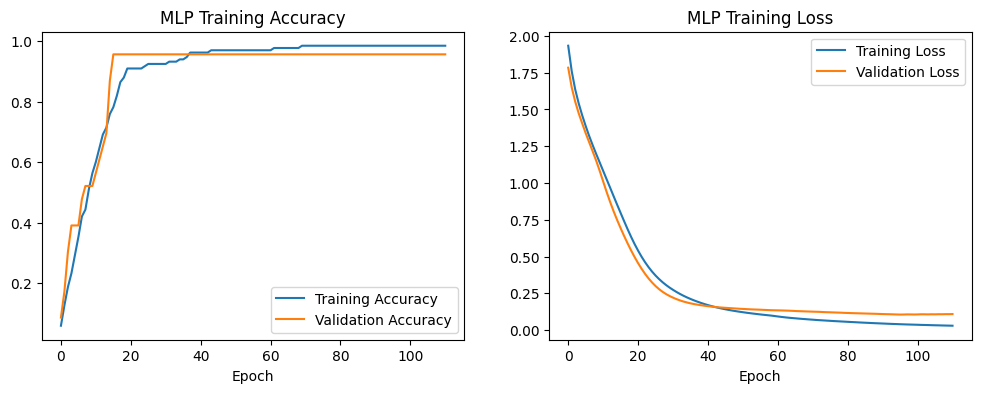

In [17]:
import numpy as np, tensorflow as tf, random
from keras.callbacks import EarlyStopping

# Reproducibility — samakan seed seperti notebook lain (seed 42)
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# One-hot encode label target untuk Keras
y_train_encoded = to_categorical(y_train, num_classes=5)
y_test_encoded  = to_categorical(y_test, num_classes=5)

# --- Validation split berbasis SUBJECT (hindari kebocoran antar-orang) ---
# Sisihkan 1 subject dari train sebagai validation, sisanya untuk fit.
# Ini konsisten dengan GroupKFold yang dipakai di RF.
val_subject = train_df['participant_id'].unique()[-1]   # ambil 1 subject sebagai val
print(f"Validation subject (dipisah dari training): '{val_subject}'\n")

val_mask   = (train_df['participant_id'] == val_subject).values
X_tr_final = X_train_scaled[~val_mask]
y_tr_final = y_train_encoded[~val_mask]
X_val      = X_train_scaled[val_mask]
y_val      = y_train_encoded[val_mask]

print(f"Train final : {X_tr_final.shape}, Validation : {X_val.shape}")

# Rancang Model MLP Mini (dangkal & hemat -> muat di ESP32-S3)
mlp_model = Sequential([
    Input(shape=(len(feature_cols),), name="input_layer"),
    Dense(16, activation='relu', name='dense_1'),
    Dense(8, activation='relu', name='dense_2'),
    Dense(5, activation='softmax', name='output_layer')
])

mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp_model.summary()

# EarlyStopping: berhenti kalau val_loss tidak membaik, ambil bobot terbaik
early_stop = EarlyStopping(monitor='val_loss', patience=15,
                           restore_best_weights=True, verbose=1)

print("\nMemulai training MLP...")
history = mlp_model.fit(
    X_tr_final,
    y_tr_final,
    epochs=200,                       # naikkan, biar EarlyStopping yang menentukan kapan stop
    batch_size=16,
    validation_data=(X_val, y_val),   # val berbasis subject, BUKAN validation_split acak
    callbacks=[early_stop],
    verbose=1
)

# Visualisasi Loss & Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MLP Training Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Training Loss'); plt.xlabel('Epoch'); plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
=== Laporan Evaluasi MLP ===
              precision    recall  f1-score   support

        idle       0.83      1.00      0.91         5
        wave       1.00      1.00      1.00         3
      rotate       1.00      1.00      1.00         2
        push       1.00      0.75      0.86         4
        lift       1.00      1.00      1.00         6

    accuracy                           0.95        20
   macro avg       0.97      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



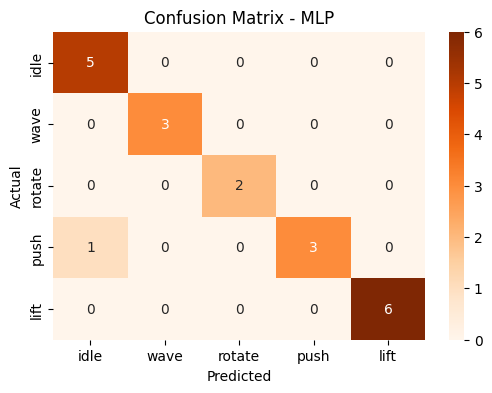

In [18]:
# Evaluasi MLP pada Test Set
y_pred_mlp_probs = mlp_model.predict(X_test_scaled)
y_pred_mlp = np.argmax(y_pred_mlp_probs, axis=1)

# Urutan label sesuai nilai numerik 0..4 (cocok dengan indeks confusion matrix)
ordered_labels = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]

print("=== Laporan Evaluasi MLP ===")
print(classification_report(y_test, y_pred_mlp, target_names=ordered_labels, zero_division=0))

# Confusion Matrix MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges',
            xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. Tabel Perbandingan Performa Akhir
Mari kita bandingkan secara head-to-head hasil Accuracy, Precision, Recall, dan F1-Score dari ketiga model yang telah dilatih.

In [19]:
compare_metrics = []
models_list = [
    ('Dummy Classifier (Baseline)', y_pred_dummy),
    ('Random Forest (Pembanding)', y_pred_rf),
    ('MLP (Model Utama/Deploy)', y_pred_mlp)
]

for name, y_pred in models_list:
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    compare_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_compare = pd.DataFrame(compare_metrics)
print("========================= PERBANDINGAN PERFORMA MODEL =========================")
print(df_compare.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

========================= PERBANDINGAN PERFORMA MODEL =========================
                      Model  Accuracy  Precision  Recall  F1-Score
Dummy Classifier (Baseline)     0.350      0.385   0.350     0.356
 Random Forest (Pembanding)     0.950      0.957   0.950     0.948
   MLP (Model Utama/Deploy)     0.950      0.958   0.950     0.949


## 9. Konversi Model MLP ke TensorFlow Lite (`model.tflite`)
Langkah terakhir dari sisi AI adalah mengonversi model Keras `.h5` / object ke format TFLite agar bisa dijalankan menggunakan library TensorFlow Lite Micro pada mikrokontroler.

In [20]:
# Konverter keras model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(mlp_model)
tflite_model = converter.convert()

tflite_file_path = "model.tflite"
with open(tflite_file_path, "wb") as f:
    f.write(tflite_model)

print(f"Model TFLite berhasil dikonversi dan disimpan ke: {tflite_file_path}")
print(f"Ukuran model TFLite: {len(tflite_model)} byte")

# === Sanity check: pastikan TFLite menghasilkan prediksi yang SAMA dengan Keras ===
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

mismatch = 0
n_check = min(len(X_test_scaled), 20)
for i in range(n_check):
    x = X_test_scaled[i:i+1].astype(np.float32)
    interpreter.set_tensor(inp['index'], x)
    interpreter.invoke()
    pred_tflite = np.argmax(interpreter.get_tensor(out['index'])[0])
    pred_keras  = np.argmax(mlp_model.predict(x, verbose=0)[0])
    if pred_tflite != pred_keras:
        mismatch += 1

print(f"\nSanity check TFLite vs Keras: {n_check - mismatch}/{n_check} cocok.")
if mismatch == 0:
    print("✅ Konversi TFLite konsisten dengan model Keras.")
else:
    print("⚠️ Ada perbedaan prediksi — periksa konversi sebelum deploy.")

INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpouj5u87p\assets


INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpouj5u87p\assets


Saved artifact at 'C:\Users\LENOVO\AppData\Local\Temp\tmpouj5u87p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 36), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2960961772752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2960961769104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2960961770256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2960961767760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2960961772368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2960961771600: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model TFLite berhasil dikonversi dan disimpan ke: model.tflite
Ukuran model TFLite: 5340 byte


d:\Python\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Sanity check TFLite vs Keras: 20/20 cocok.
✅ Konversi TFLite konsisten dengan model Keras.


## 10. Ekspor Model TFLite ke C++ Array Header (`model.h`)
Agar model dapat ditanamkan langsung dalam kode program Arduino IDE/ESP-IDF pada ESP32, kita akan mengubah format biner `.tflite` menjadi array array byte bertipe `const unsigned char` C++.

In [21]:
def export_to_cpp_header(tflite_path, c_header_path, array_name="g_model"):
    with open(tflite_path, 'rb') as f:
        content = f.read()

    # Ubah binary menjadi hex strings
    hex_list = [f"0x{b:02x}" for b in content]

    # Format hex list menjadi rapi (12 elemen per baris)
    hex_rows = ""
    for i in range(0, len(hex_list), 12):
        chunk = hex_list[i : i + 12]
        hex_rows += "  " + ", ".join(chunk) + ",\n"

    # Bersihkan koma+newline terakhir DI LUAR f-string (hindari error backslash di Python <3.12)
    clean_rows = hex_rows.rstrip(",\n")

    # Buat konten header C++
    header_content = f"""// File ini dihasilkan secara otomatis dari hasil pelatihan model MLP Keras.
// Konfigurasi: 36 input fitur, 5 kelas output.

#ifndef MODEL_DATA_H
#define MODEL_DATA_H

// Ukuran file model.tflite dalam byte
const unsigned int {array_name}_len = {len(content)};

// Byte array representasi biner model TFLite Micro
const unsigned char {array_name}[] alignas(16) = {{
{clean_rows}
}};

#endif // MODEL_DATA_H
"""

    with open(c_header_path, 'w') as f:
        f.write(header_content)

    print(f"C++ Header file berhasil dibuat di: {c_header_path}")

# Jalankan ekspor
export_to_cpp_header("model.tflite", "model.h")

# === Verifikasi otomatis: pastikan model.h konsisten dengan model.tflite ===
import re
with open("model.h") as f:
    txt = f.read()

n_bytes      = len(re.findall(r'0x[0-9a-f]{2}', txt))
len_tertulis = int(re.search(r'g_model_len = (\d+)', txt).group(1))
ukuran_asli  = len(open("model.tflite", "rb").read())

print(f"\n--- Verifikasi model.h ---")
print(f"Jumlah byte di array  : {n_bytes}")
print(f"g_model_len tertulis  : {len_tertulis}")
print(f"Ukuran model.tflite   : {ukuran_asli}")
if n_bytes == len_tertulis == ukuran_asli:
    print("✅ KONSISTEN. model.h siap disalin ke folder Arduino.")
else:
    print("⚠️ TIDAK COCOK — jangan deploy sebelum diperiksa.")

C++ Header file berhasil dibuat di: model.h

--- Verifikasi model.h ---
Jumlah byte di array  : 5340
g_model_len tertulis  : 5340
Ukuran model.tflite   : 5340
✅ KONSISTEN. model.h siap disalin ke folder Arduino.
